# Absorption of Conjugated Dyes with the Finite Well


<div>
  <center> <img width="550" src="https://github.com/act-cms/absorption-of-conjugated-dyes-with-finite-well-PIB/blob/dev/02_absorption-conjugated-dyes-activity/Figures/Fig6_UVvis.png?raw=True"> </center>
</div>


This notebook was adapted for the following publication:

* Patel, P. Modernizing Physical Chemistry: Integrating Computational Chemistry, the Finite Well, and Python Data Visualization in the Particle-in-a-Box Experiment. In *Engaging Students in Physical Chemistry, Volume 2; ACS Symposium Series*; American Chemical Society, **2025**; Vol. 1515, pp 261–278. https://doi.org/doi:10.1021/bk-2025-1515.ch017.

:::{admonition} Overview
**Science Questions:**
- How does the particle-in-a-box (PIB) model connect to UV-vis spectroscopy?
- How does this connection extend to the finite well model?

**Programming Objectives:**
- Use a for loop to plot the computed UV-vis spectra.
- Overlay the computed and experimental spectra.
- Determine the computed $\lambda_{max}$ from the various models and spectra.
:::

::::{hint} Quantum Background
:icon:false

:::{note} Infinite Well

In the particle-in-a-box (PIB) model, a particle is confined to moving in the x-dimension of a box of length L. The potential, $V(x)$, is zero inside the box ($0 ≤ x ≤ L$) while $V(x)$ is infinite outside the box ($x ≤ 0$ and $x ≥ L$). Confining the particle inside a one-dimensional (1D) box leads to a quantization of allowed energies. Outside the box, $V(x)$ is infinite and thus, $\Psi(x)$ is zero. In quantum mechanical terms, $\Psi^2(x)$ being zero outside the box means there is zero-probability of finding the particle outside the box.

<div>
  <center> <img width="700" src="https://github.com/act-cms/absorption-of-conjugated-dyes-with-finite-well-PIB/blob/dev/02_absorption-conjugated-dyes-activity/Figures/Fig1_PIB_Infinite.png?raw=True"> </center>
</div>

Far from being only a pedagogical and mathematical exercise, confining a particle to moving in a 1D box has applications in predicting properties of dye molecules that can be measured. The energy levels predicted by solutions to the 1D PIB problem may be used to predict the maximum absorption wavelength, $\lambda_{max}$, for some chemical compounds that absorb light in the visible spectrum. Such compounds generally have delocalized electrons from either the $\pi$ electrons in a conjugated organic molecule or the odd electron in a free radical species.

:::

:::{note} Computational Chemistry
Computational chemistry has advanced with the digital age, offering critical insight into chemical processes and properties that are difficult to measure experimentally. Beyond predictive capabilities, computational chemistry can also reinforce the conceptual foundations of the PIB model. For example, consider the figure below, which shows how the 1D PIB framework maps onto (3E, 5E, 7E)-1,3,5,7,9-decapentaene. Computed molecular orbitals (MOs) visually encode the same nodal behavior and energy spacing consistent with the PIB model, illustrating how computational tools can bridge fundamental quantum models with observable molecular behavior.

<div>
  <center> <img width="700" src="https://github.com/act-cms/absorption-of-conjugated-dyes-with-finite-well-PIB/blob/dev/02_absorption-conjugated-dyes-activity/Figures/Fig2_PIB.png?raw=True"> </center>
</div>

:::
::::

## Import Packages

In [ ]:
#Import standard packages
import numpy as np
import os,sys,re # Import regex
import pandas as pd # DataFrame analysis
%pip install openpyxl --quiet

# Plotting
import matplotlib
matplotlib.rcParams.update({'font.size': 20})
import matplotlib.pyplot as plt

# Plotting
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D # 3D plots
from matplotlib import cm # Colormaps
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

#Inset figures into plots
from matplotlib.offsetbox import TextArea, DrawingArea, OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

#Create lines for custom legends
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

# Numerical solver in scipy
import scipy
from scipy.optimize import fsolve

from glob import glob
import warnings

# Insert a progress bar to show the progress of the script
from tqdm.notebook import tqdm, tnrange, trange

# Py3Dmol for visualizing molecules
import py3Dmol

#ASE for molecule calculations
from ase.io import read

#Quizzes and Animations
from IPython.display import display, HTML, clear_output
import time

%pip install "jupyterquiz" --quiet
from jupyterquiz import display_quiz

import quiz_utils      # Now you can import it directly

# Part 1. Combining Experimental and Computational Spectra

## 1.1 Import your experimental and computational data

The experimental data from the UV-vis will be in a csv format, so use `pd.read_csv()` instead of `pd.read_excel()`.

In [92]:
# Import your experimental data
dye1_exp=pd.read_csv('Sample-Data/dye1_exp.csv')
dye2_exp=pd.read_csv('Sample-Data/dye2_exp.csv')
dye3_exp=pd.read_csv('Sample-Data/dye3_exp.csv')

# Import your computational data
dye1_comp=pd.read_csv('Sample-Data/dye1_comp.csv')
dye2_comp=pd.read_csv('Sample-Data/dye2_comp.csv')
dye3_comp=pd.read_csv('Sample-Data/dye3_comp.csv')


## 1.2 Converting the computed values to a spectrum

The extracted results from the ORCA calculations contain information about the excitation wavelength ($\lambda$) and the oscillator strength ($f$). You will need to broaden each transition using

$$\varepsilon_i(\lambda)=1.3062974*10^8\dfrac{f_i}{\sigma} \text{exp}\bigg[-\bigg(\dfrac{1/\lambda-1/\lambda_i}{\sigma}\bigg)^2\bigg]$$

where $i$ represents the $i^\text{th}$ electronic excitation, $\lambda$ is the excitation wavelength in nm, $f_i$ is the oscillator strength (a.u.), and $\sigma$ is the parameter for peak broadening. Setting $\sigma$ = 0.2 eV = 1/6199.2 nm$^{-1}$ = 10$^{7}$/6199.2 cm$^{-1}$ will result in the following reduction

$$	\varepsilon_i(\lambda)=1.3062974*10^8\dfrac{f_i}{10^{7}/6199.2} \text{exp}\bigg[-\bigg(\dfrac{1/\lambda-1/\lambda_i}{1/6199.2}\bigg)^2\bigg]
$$

Equation 2 above refers to how to broaden a single transition whereas the next equation covers how to do the sum of all the individual excitations.

$$
	\varepsilon(\lambda)=\sum_{i=1}^{n}\varepsilon_i(\lambda)=\sum_{i=1}^{n}\bigg(1.3062974*10^8\dfrac{f_i}{10^{7}/6199.2} \text{exp}\bigg[-\bigg(\dfrac{1/\lambda-1/\lambda_i}{1/6199.2}\bigg)^2\bigg]\bigg)
$$

In Equation 3, your wavelengths ($\lambda$) are the x-values and $\lambda_i$ is the computed wavelength corresponding to the transition with oscillator strength $f_i$.

**Below is the Python form of Equation 2. You will use this function to broaden your computed peaks.**

In [93]:
# @title Define the broaden_peaks_gaussian function

def broaden_peak_gaussian(X,h,f,sigma=1/3099.6/2.5):
  '''
  X: wavelength range
  h: individual peak wavelength (in nm)
  f: oscillator strength
  sigma: broadening parameter (as factors of 1/3099.6/x where you want to change x as needed)
  '''

  f2=1e7*sigma
  A=1.3062974*10**8
  e1=1/h-1/X

  return A*(f/f2)*np.exp(-(e1/sigma)**2)

In [62]:
%run Broadening.py

interactive(children=(IntSlider(value=1, continuous_update=False, description='# Peaks:', max=20, min=1, style…

:::{danger} ❓ Question 1
:icon: false
Explain how the quantized transition energies correspond to peaks in the spectra.
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> Absorption peaks occur because electrons can only occupy quantized energy levels. A peak appears when a photon has exactly the right energy to promote an electron from the HOMO to the LUMO (or another allowed transition), where $\Delta E= \dfrac{hc}{\lambda}$. However, if the individual transitions are close enough in energy, then those quantized peaks can appear as a single broader peak depending on instrument resolution.
:::::

## 1.3 Plot the combined experimental and computed spectra


::::{hint} 🐍 Matplotlib Customization
:icon:false

:::{note} Importing Inset Figures

Sometimes, you don't want to use PowerPoint or other software to combine images together because of loss of resolution, or the extra time to make sure everything is correct. There are packages to create offset images that we can use to import images into a matplotlib figure:

```{code}python
# Packages to inset figures into plots (already loaded)
from matplotlib.offsetbox import TextArea, DrawingArea, OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
```
:::

:::{note} Custom Legends
:icon: false
Sometimes, you need a custom legend beyond what labels in a `plt.plot()` provides. To create a custom legend, the following packages can be imported:

```{code}python
# Create lines for custom legends (already imported in this notebook)
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
```

The code block below can be used to create custom legends that are independent of the labels given inside a <code>plt.plot()</code> command.

```{code}python
# Copy this block here and edit accordingly for a custom legend
custom_lines = [Line2D([0], [0], color='C0', lw=3),
                Line2D([0], [0], color='k', lw=3,)]
ax1.legend(custom_lines, ['Computed', 'Experiment'],fontsize=20)
```

In the code block above, the 'C0' is the default blue color and is used to label the 'Computed' spectrum whereas the 'k' is black and is used to label the 'Experimental' spectrum.

:::::::

:::{warning} ✏️ Exercise
:icon: false
- Combine everything (custom legends, loops, `broaden_peak_gaussian`, etc.) to plot a combined figure of the computed and experimental spectra (see below).
- Create a two-axis plot to simultaneously plot the computed and experimental spectra on the same image.
- Either use a for loop or a function to repeat the task for all three dyes.

<div>
  <center> <img width="700" src="https://github.com/act-cms/absorption-of-conjugated-dyes-with-finite-well-PIB/blob/dev/02_absorption-conjugated-dyes-activity/Figures/Fig6_UVvis.png?raw=True"> </center>
</div>
:::

In [ ]:
plt.plot(dye1.Wavelength,dye1.Absorbance)


In [108]:
# Define the linear space for your computed spectra
xmin=  100       # Min wavelength
xmax=  800       # Max wavelength

X= np.linspace(xmin,xmax,5001)

# Start off with a list of zeros.
comp_spec_dye1=np.zeros(len(X))
comp_spec_dye2=np.zeros(len(X))
comp_spec_dye3=np.zeros(len(X))

# Create the for loop to loop through all twenty peaks with the broaden_peak_gaussian function
# You will use the += operation to add the contributions of each computed peak
for i in range(len(dye1_comp)):
    comp_spec_dye1+=broaden_peak_gaussian(X,dye1_comp.Wavelength[i],dye1_comp.f[i])
    comp_spec_dye2+=broaden_peak_gaussian(X,dye2_comp.Wavelength[i],dye2_comp.f[i])
    comp_spec_dye3+=broaden_peak_gaussian(X,dye3_comp.Wavelength[i],dye3_comp.f[i])

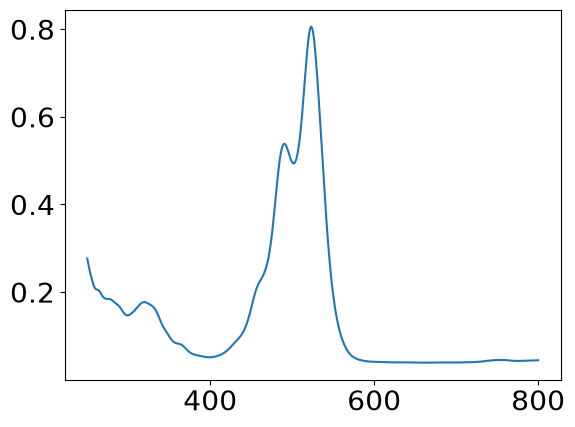

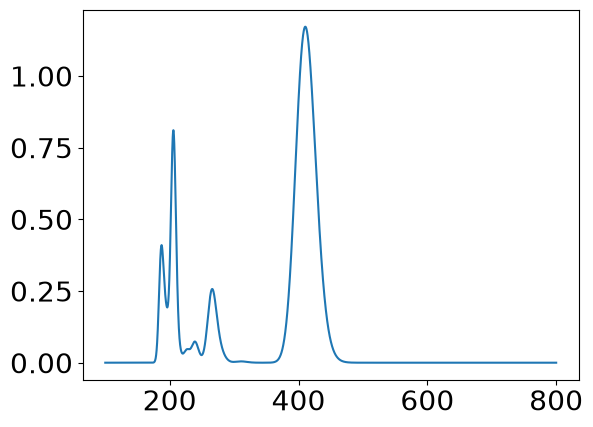

In [115]:
plt.plot(dye1.Wavelength,dye1.Absorbance)
plt.show()
plt.plot(X,comp_spec_dye1*2.5e-10)

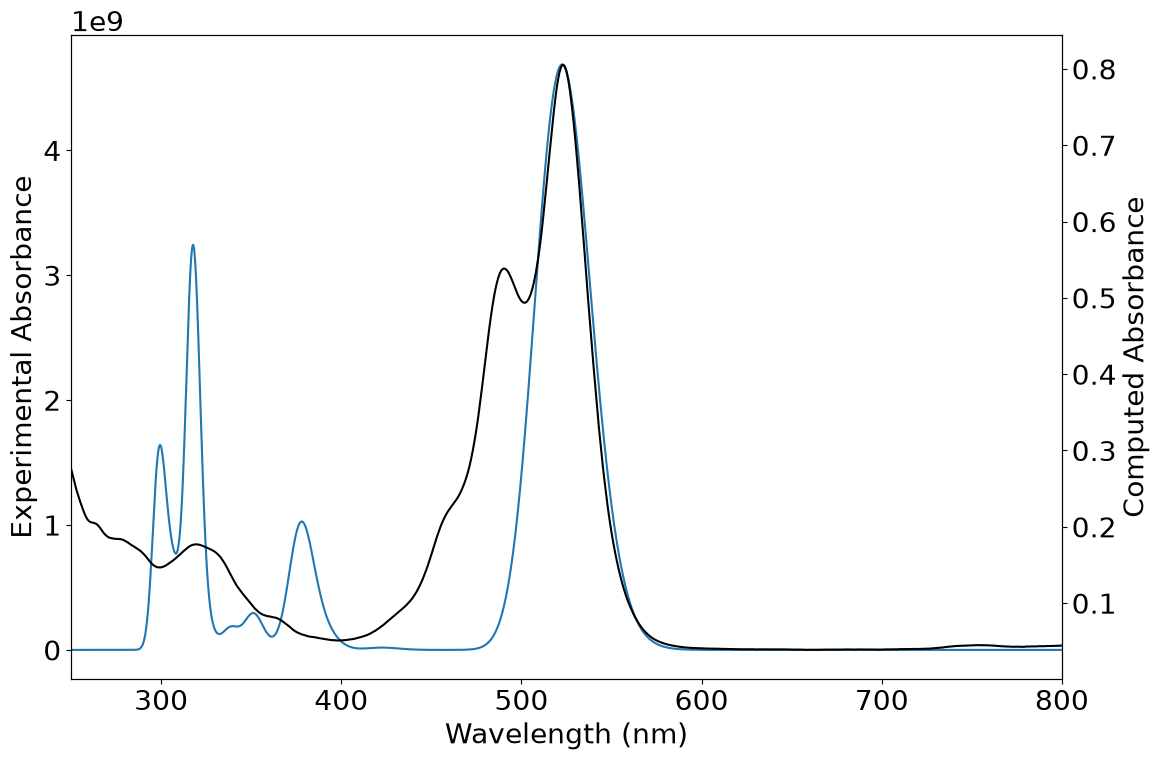

In [125]:
# Use a twin axis to plot the computed spectrum on one axis and the experimental spectrum on a twin second axis
# This allows for qualitative comparisons since intensities are relative.

fig, ax1 = plt.subplots(figsize=(12,8))
ax2 = ax1.twinx() # Create a dual-axis plot


# Plot the computed spectra (data) and the vertical lines (transitions)
# Shift the x values by the difference between the computed and experimental peaks
ax1.plot(X+112,comp_spec_dye1,'C0')

# Plot the experimental UV-Vis data
ax2.plot(dye1_exp.Wavelength,dye1_exp.Absorbance,'k')
#plt.plot(dye2.Wavelength,dye2.Absorbance)
#plt.plot(dye3.Wavelength,dye3.Absorbance)

# Grabs the default axes limits
#ymin1,ymax1=ax1.get_ylim()
#ymin2,ymax2=ax2.get_ylim()

# Set the bounds on each axis by changing the values inside the parentheses
#ax1.set_ylim(ymin1,ymax2)
#ax2.set_ylim(ymin2,ymax2)

#Set the x limits to the experimental spectral range (250-800 nm)
ax1.set_xlim(250,800)
# Label the axes in a subplot using the Axes methods set_xlabel() and set_ylabel()
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Experimental Absorbance')
ax2.set_ylabel('Computed Absorbance')

plt.tight_layout()

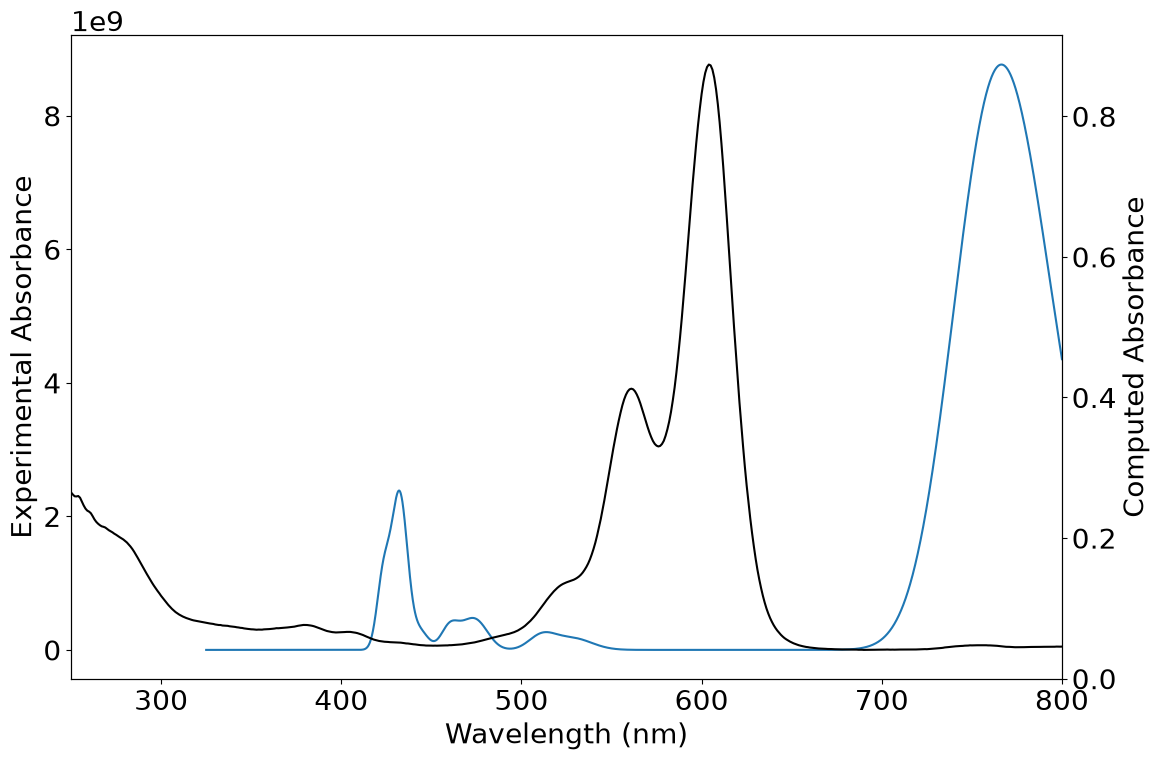

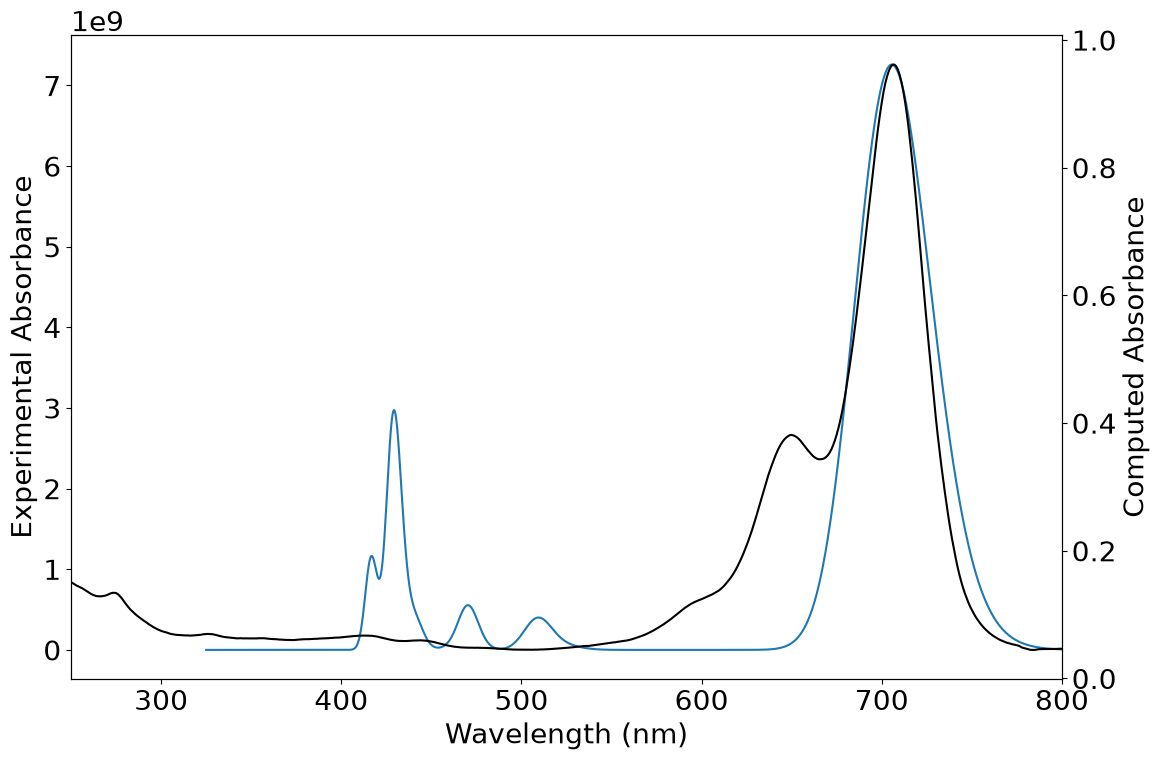

In [129]:
# Repeat this for dyes 2 and 3 so you have figures for all the dyes

# Use a twin axis to plot the computed spectrum on one axis and the experimental spectrum on a twin second axis
# This allows for qualitative comparisons since intensities are relative.

fig, ax1 = plt.subplots(figsize=(12,8))
ax2 = ax1.twinx() # Create a dual-axis plot


# Plot the computed spectra (data) and the vertical lines (transitions)
# Shift the x values by the difference between the computed and experimental peaks
ax1.plot(X+225,comp_spec_dye3,'C0')

# Plot the experimental UV-Vis data
ax2.plot(dye3_exp.Wavelength,dye3_exp.Absorbance,'k')
#plt.plot(dye2.Wavelength,dye2.Absorbance)
#plt.plot(dye3.Wavelength,dye3.Absorbance)

# Grabs the default axes limits
#ymin1,ymax1=ax1.get_ylim()
#ymin2,ymax2=ax2.get_ylim()

# Set the bounds on each axis by changing the values inside the parentheses
#ax1.set_ylim(ymin1,ymax2)
#ax2.set_ylim(ymin2,ymax2)

#Set the x limits to the experimental spectral range (250-800 nm)
ax1.set_xlim(250,800)
# Label the axes in a subplot using the Axes methods set_xlabel() and set_ylabel()
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Experimental Absorbance')
ax2.set_ylabel('Computed Absorbance')

plt.tight_layout()

# Repeat this for dyes 2 and 3 so you have figures for all the dyes
# Use a twin axis to plot the computed spectrum on one axis and the experimental spectrum on a twin second axis
# This allows for qualitative comparisons since intensities are relative.

fig, ax1 = plt.subplots(figsize=(12,8))
ax2 = ax1.twinx() # Create a dual-axis plot


# Plot the computed spectra (data) and the vertical lines (transitions)
# Shift the x values by the difference between the computed and experimental peaks
ax1.plot(X+225,comp_spec_dye2,'C0')

# Plot the experimental UV-Vis data
ax2.plot(dye2_exp.Wavelength,dye2_exp.Absorbance,'k')
#plt.plot(dye2.Wavelength,dye2.Absorbance)
#plt.plot(dye3.Wavelength,dye3.Absorbance)

# Grabs the default axes limits
#ymin1,ymax1=ax1.get_ylim()
#ymin2,ymax2=ax2.get_ylim()

# Set the bounds on each axis by changing the values inside the parentheses
#ax1.set_ylim(ymin1,ymax2)
#ax2.set_ylim(ymin2,ymax2)

#Set the x limits to the experimental spectral range (250-800 nm)
ax1.set_xlim(250,800)
# Label the axes in a subplot using the Axes methods set_xlabel() and set_ylabel()
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Experimental Absorbance')
ax2.set_ylabel('Computed Absorbance')

plt.tight_layout()



:::{note} Inset Figures

The code below is a sample of how to create inset images within Python. Sometimes, you don't want to use PowerPoint or other software to combine images together because of loss of resolution, or the extra time to make sure everything is correct. So, there are packages to create offset images that we can use to import images into a matplotlib figure.

```{code}python
# Load an image (PNG/JPG/etc.)
img = mpimg.imread("/content/...")   # path to your image

fig, ax = plt.subplots(figsize=(5, 4))

# Plot your data
ax.plot([0, 1, 2, 3], [0, 2, 1, 3])

# Create the inset image object
imagebox = OffsetImage(img, zoom=0.1)   # zoom adjusts size

# Create an annotation box to place it
ab = AnnotationBbox(
    imagebox,
    (1.0, 3.0),       # (x, y) position in data coordinates
    frameon=False,    # If True, draws a box around the inset
)

# Add to the axes
ax.add_artist(ab)

plt.show()

:::

In [ ]:
# Play around with inset figures with your orbital pictures if you want



# Part 2. Quantum mechanically, what causes a spectroscopic peak?

In spectroscopy, chemists often combine experimental and computational techniques to gain insight into spectroscopic features. For UV-vis spectroscopy, we can investigate the molecular orbitals to see which ones correspond to specific spectroscopic peaks.

In [40]:
#

# Create the orbital dictionary and include the TDDFT snapshot to indicate which orbitals to select. Have a student question indicate which orbitals are correct in
# a question

# Have students realize that these are in fact the same wavefunctions observed in infinite particle in a box. Use flat dye2 as the model system. Only use representative system.

In [4]:
quiz_utils.json_to_quiz('rotation4.json','lab-4-1')

<IPython.core.display.Javascript object>

:::{danger} ❓ Question 2
:icon: false
What feature of the molecular orbitals makes the particle-in-a-box model useful for describing the electronic transition in this molecule?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> The nodal patterns of the frontier molecular orbitals (HOMO and LUMO) resemble the standing-wave solutions of a particle in a box.
:::::

In [5]:
quiz_utils.json_to_quiz('rotation4.json','lab-4-2')

<IPython.core.display.Javascript object>

# Part 3. Modeling the Finite Well

The finite well model extends the 1D infinite potential well by introducing finite barriers, allowing for quantum tunneling and wavefunctions that decay into the barrier regions. This results in lower, more closely spaced energy levels and offers a more realistic approximation of electron behavior in molecules. Computational chemistry techniques reinforce this connection by visualizing MOs of the 3D geometry, which leads to an estimation of the effective box length and well depth. Rendering MOs in the context of a finite well also helps illustrate how the well depth limits the number of bound states, highlighting where the particle-in-a-box approximation breaks down and higher energy orbitals begin to resemble unbound or delocalized states. **By combining these computational insights with the finite well model, this notebook will demonstrate how to use the finite well approximation as a predictive tool for absorption spectra.**

<div>
  <center> <img width="500" src="https://github.com/act-cms/absorption-of-conjugated-dyes-with-finite-well-PIB/blob/dev/02_absorption-conjugated-dyes-activity/Figures/Fig3_finitewell.png?raw=True"> </center>
</div>

Consider a particle in a finite well model where
\begin{align}
	k_0 &= \sqrt{\dfrac{2m_e}{\hbar}(V_0-E)}\
	k_1 &= \sqrt{\dfrac{2m_eE}{\hbar^2}}
\end{align}
To determine the energy eigenvalues from the wavefunction, we begin the derivation where $\Psi_\text{I}(x)$ and $\Psi_\text{II}(x)$ must follow the boundary conditions at x=0, i.e., $\Psi_\text{I}(0)=\Psi_\text{II}(0)$ and $\Psi'_\text{I}(0)=\Psi'_\text{II}(0)$.

\begin{align}
	Ae^{k_0(0)} &= Bsin(k_1*0)+Ccos(k_1*0)\
	Ak_0e^{k_0(0)} &= Bk_1cos(k_1*0)-Ck_1sin(k_1*0) 
\end{align}

By solving the system of equations above,

\begin{align}
	C&=A \
	B&=A\frac{k_0}{k_1} 
\end{align}

At x=L, the system of equations containing $\Psi(L)$ and $\Psi'(L)$ is

\begin{align}
	De^{-k_0L} &= Bsin(k_1L)+Ccos(k_1L)\\
	De^{-k_0L} &= Bk_1cos(k_1L)-Ck_1sin(k_1L)
\end{align}

By algebra,

\begin{align}
	Dk_0e^{-k_0L} &= A\dfrac{k_0^2}{k_1}sin(k_1L)+Ak_0cos(k_1L) \\
	Dk_0e^{-k_0L} &= -A\dfrac{k_0}{k_1}k_1cos(k_1L)+Ak_1sin(k_1L))
\end{align}

By equality, the above equations may be solved for the quantity $Dk_0e^{-k_0L}$

\begin{align}
	\dfrac{k_0^2}{k_1}sin(k_1L)+k_0cos(k_1L) &= -k_0cos(k_1L)+k_1sin(k_1L) \\
	k_0^2sin(k_1L)+k_1k_0cos(k_1L) &= -k_1k_0cos(k_1L)+k_1^2sin(k_1L)\\
	2k_1k_0cos(k_1L) &= (k_1^2-k_0^2)sin(k_1L)
\end{align}

\begin{equation}
	2k_1k_0 = (k_1^2-k_0^2)tan(k_1L)
\end{equation}

By substituting $k_0$ and $k_1$ into the above equation,

\begin{equation}
	2\bigg(\dfrac{2m_eE}{\hbar^2}\bigg)\sqrt{E(V_0-E)} = \bigg(\dfrac{2m_eE}{\hbar^2}-\dfrac{2m_e(V_0-E)}{\hbar^2}\bigg)tan\bigg(\sqrt{\dfrac{2m_eEL^2}{\hbar^2}}\bigg)
\end{equation}

\begin{equation}
	\dfrac{2\sqrt{E(V_0-E)}}{2E-V_0} = tan\bigg(\sqrt{\dfrac{2m_eEL^2}{\hbar^2}}\bigg)
\end{equation}

Solving Equation 12 for $E$ correspond to the energy levels of the finite well. You will plot these functions here to solve for all values of $E$.

For this module, let
\begin{align}
f(x) &= \dfrac{2\sqrt{E(V_0-E)}}{2E-V_0}\\
g(x) &= tan\bigg(\sqrt{\dfrac{2m_eEL^2}{\hbar^2}}\bigg)
\end{align}

## 3.1 Set up the model

:::{warning} ✏️ Exercise: Finite Well Model
:icon: false
Fill in the blanks in the following code blocks to construct the functions used to compute the finite well.
:::

### Define the constants and conversion factors

In [17]:
eV2J=1.602e-19 # Convert from eV to J
h=6.62606957e-34 # Planck's constant (J·s)
hbar= h/(2*np.pi) # ℏ in J·s (formula)
me=9.11e-31 # mass of electron in kg (3 sig figs)

### Define the functions

In [18]:
def f(Ei,V0):
  '''Ei is in eV'''
  '''V0 is in eV'''
  E= Ei*eV2J
  V= V0*eV2J
  # Suppress RuntimeWarning for invalid value encountered in sqrt
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    a= 2*np.sqrt(E*(V-E))
  b= 2*E-V
  return a/b

def g(Ei,L):
  '''Ei is in eV'''
  '''L is in m'''
  E= Ei*eV2J
  a= 2*me*E*(L**2)
  b= hbar**2
  # Suppress RuntimeWarning for invalid value encountered in sqrt
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    c=np.sqrt(a/b)
  return np.tan(c)

# Define the difference function between f(x) and g(x) to help find roots
def j(x, V0_local, L_local):
  return f(x,V0_local)-g(x,L_local)

def intersections(X2,Y2,Z2):
  roots_idx = np.argwhere(np.diff(np.sign(Y2-Z2)) != 0).flatten()
  Xint = X2[roots_idx]
  return Xint[1::2]

## 3.2 Play with the model

In [19]:
%run FiniteWell.py

interactive(children=(FloatSlider(value=10.0, description='V₀ (eV)', max=30.0, min=8.0, step=0.01), FloatSlide…

:::{danger} ❓ Question 3
:icon: false
What happens as you change `V0` and `L`?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> As L increases, the box gets wider and allows for more energy levels to be present within the well. As V increases (keeping L constant), more energy levels populate the well.
::::::

## 3.3 Finding L and $V_0$ for these molecules

**What features of these molecules can be used to determine $V_0$ and L?**

By visualizing the molecular orbitals (MOs) and counting the number of nodes across the across the conjugated $\pi$ system, you can estimate both the well depth ($V_0$) and the box length (L) for the finite well for each molecule since the primary transition from the spectra is the HOMO-LUMO transition.

As the 1D PIB is used to describe the congujated $\pi$ system, the finite well should be constructed to contain all the bound MOs spanning the range of HOMO-$n$ to LUMO+$m$ where $n$ and $m$ are intergers. The primary goal is to use the complex MO results to inform and calibrate a more intuitive use of the finite well approximation.

The box length will be determined as the edge of the conjugated $\pi$ system connecting the quinoline moieties.


### Determining L
:::{warning} ✏️ Exercise: Determining L
:icon: false
Use the `render_atom_labels()`, `calc_bond_distance()`, and `render_box_length()` pre-made Python functions below to determine the length of the box (L).

The length of the box will be the Euclidean distance between the $C$ atoms outside of the $N$ atoms in the chain. Take the chain between the $N$ atoms and add the carbons in the ring that form a linear chain.
:::

In [15]:
# Import your 3D molecule coordinates from Sample-Data
mol1 = read('Sample-Data/dye1.xyz')
mol2 = read('Sample-Data/dye2.xyz')
mol3 = read('Sample-Data/dye3.xyz')

In [16]:
def render_atom_labels(mol):
    ''' This function uses the atomic simulation environment to render a mol object using py3Dmol with atom index labels
    '''
    
    xyz_lines = [str(len(mol)), "Optimized with GFN2-XTB"]
    for atom in mol:
        x, y, z = atom.position
        xyz_lines.append(f"{atom.symbol}  {x:.5f}  {y:.5f}  {z:.5f}")
    xyz_str = "\n".join(xyz_lines)

    # Render the molecule in 3D
    ELEMENT_COLORS = {
    "C": "#4a4a4a",
    "N": "#3b7ec5",
    "H": "#888888",
    "O": "#c0392b",
    "S": "#c8a000",
    }
    
    DEFAULT_COLOR = "#555555"

    view = py3Dmol.view(width=800, height=520)
    view.addModel(xyz_str, "xyz")   # xyz_str built in Cell 5; re-run Cell 5 first if not defined
    
    # Base style
    view.setStyle({}, {"stick":  {"radius": 0.10, "colorscheme": "Jmol"},
                       "sphere": {"radius": 0.25, "colorscheme": "Jmol"}})
    
    # Add an index label at every atom position
    for i, atom in enumerate(mol):
        if(atom.symbol=='C' or atom.symbol=='N'):
            x, y, z = atom.position.tolist()
            color = ELEMENT_COLORS.get(atom.symbol, DEFAULT_COLOR)
            view.addLabel(
                f"{i}:{atom.symbol}",
                {
                    "position":          {"x": x, "y": y, "z": z},
                    "backgroundColor":   color,
                    "fontColor":         "white",
                    "fontSize":          14,
                    "backgroundOpacity": 0.80,
                    "inFront":           True,   # always visible through the molecule
                }
            )
    
    view.zoomTo()
    view.show()
    return mol

def calc_bond_distance(mol, ATOM_A, ATOM_B):
    '''
        Provide a mol object and indices for two atoms to calculate the Euclidean distance, i.e., the "bond" distance, between atoms A and B

        For example, 
        ATOM_A = 9   # e.g. N at index 9
        ATOM_B = 24   # e.g. N at index 24
    '''
    
    # Using ASE (Atomic Simulation Environment) to calculate bond lengths
    pos_a = mol[ATOM_A].position
    pos_b = mol[ATOM_B].position
    distance = np.linalg.norm(pos_a - pos_b)
    
    sym_a = mol[ATOM_A].symbol
    sym_b = mol[ATOM_B].symbol
    
    print(f"Euclidean distance  ({sym_a}{ATOM_A} ↔ {sym_b}{ATOM_B})  =  {distance:.6f} Å")

def render_box_length(mol,ATOM_A,ATOM_B):
    ''' This function uses ASE to render the molecules in 3D and show the distance between both atoms'''
    
    xyz_lines = [str(len(mol)), "Generated from ASE"]
    for atom in mol:
        x, y, z = atom.position
        xyz_lines.append(f"{atom.symbol}  {x:.5f}  {y:.5f}  {z:.5f}")
    xyz_str = "\n".join(xyz_lines)

    pos_a = mol[ATOM_A].position
    pos_b = mol[ATOM_B].position
    distance = np.linalg.norm(pos_a - pos_b)
    
    sym_a = mol[ATOM_A].symbol
    sym_b = mol[ATOM_B].symbol

    # ── viewer setup ────────────────────────────────────────────────────────
    view = py3Dmol.view(width=800, height=500)
    view.addModel(xyz_str, "xyz")
    
    # Default style: stick + small sphere
    view.setStyle({}, {"stick": {"radius": 0.12, "colorscheme": "Jmol"},
                       "sphere": {"radius": 0.28, "colorscheme": "Jmol"}})
    
    # Highlight atom A (green) and atom B (orange)
    view.setStyle({"serial": ATOM_A },   # py3Dmol uses 1-based serials
                  {"sphere": {"radius": 0.55, "color": "#3fb950"},
                   "stick":  {"radius": 0.18, "color": "#3fb950"}})
    
    view.setStyle({"serial": ATOM_B },
                  {"sphere": {"radius": 0.55, "color": "#f0883e"},
                   "stick":  {"radius": 0.18, "color": "#f0883e"}})
    
    # Dashed cyan line between the two atoms
    ax, ay, az = pos_a.tolist()
    bx, by, bz = pos_b.tolist()
    
    view.addCylinder({
        "start": {"x": ax, "y": ay, "z": az},
        "end":   {"x": bx, "y": by, "z": bz},
        "radius": 0.06,
        "fromCap": 1, "toCap": 1,
        "color": "#58a6ff",
        "dashed": True,
        "opacity": 0.9
    })
    
    # Label atoms and show distance at midpoint
    mid = ((ax + bx) / 2, (ay + by) / 2, (az + bz) / 2)
    
    view.addLabel(f"{sym_a}{ATOM_A}",
                  {"position": {"x": ax, "y": ay, "z": az},
                   "backgroundColor": "#3fb950", "fontColor": "white",
                   "fontSize": 12, "backgroundOpacity": 0.85})
    
    view.addLabel(f"{sym_b}{ATOM_B}",
                  {"position": {"x": bx, "y": by, "z": bz},
                   "backgroundColor": "#f0883e", "fontColor": "white",
                   "fontSize": 12, "backgroundOpacity": 0.85})
    
    view.addLabel(f"{distance:.3f} Å",
                  {"position": {"x": mid[0], "y": mid[1], "z": mid[2]},
                   "backgroundColor": "#161b22", "fontColor": "#58a6ff",
                   "fontSize": 13, "backgroundOpacity": 0.9})
    
    view.zoomTo()
    view.show()

:::{danger} ❓ Question 4
:icon: false
The code blocks above showcase three functions that we can use to determine L. Discuss with your lab partners how you would be able to use these functions to determine the box length of the molecule.
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> Use render_atom_labels to get the indices for the atoms in question for the box length.
>
> Then, use the calc_bond_distance function to calculate the Euclidean distance. The render_box_length function can be used to show the box length superimposed on the two atoms that are the boundaries.
::::::

In [20]:
# Try out you
render_atom_labels(mol1)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Atoms(symbols='C3NC2H2C3NC2H2C8H8CHCH2CH3CH2CH3', pbc=False)

In [21]:
calc_bond_distance(mol1,2,12)
calc_bond_distance(mol2,4,19)
calc_bond_distance(mol3,5,19)

Euclidean distance  (C2 ↔ C12)  =  7.418847 Å
Euclidean distance  (C4 ↔ C19)  =  10.032542 Å
Euclidean distance  (C5 ↔ C19)  =  12.480328 Å


In [22]:
render_box_length(mol1,2,12)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [23]:
# Enter your calculate box lengths in Angstrom (default value)
# We will use these for our finite well energy level calculations
L1=7.418847
L2=10.032542
L3=12.480328

### Determining $V_0$

:::{warning} ✏️ Exercise: Determining $V_0$
:icon: false
You will need the range of orbitals from HOMO-$n$ to LUMO+2 to calculate the well depth $V_0$. To do this:
1. Extract the energy levels from the ORCA output files.
2. Investigate the orbital pictures to determine which MOs below HOMO need to be included in the bound state. We are going to use LUMO+2 as an upper bound to the well.
3. Mark down the orbital energies of the identified HOMO-$n$ and LUMO+2 orbitals. The difference in energies is the first guess at the orbital energies. You may have to add 0.5-1 eV to this as a buffer (rounding also works).
4. As we are using detailed MO energies as an approximate input to the simplified finite well model, the exact value of $V_0$ is not critical to the qualitative description of the conjugated $\pi$ system.
:::

In [24]:
# Use the orca output files and do text extraction to get HOMO-10 and LUMO+2
# Have a function that extracts the MO energy levels from ORCA output



# Enter your calculated potentials here
V1=10.09
V2=11
V3=12

## 3.4 Plotting the finite well energies

:::{hint} 🐍 Note: Solving the Intersections
:icon: false
The `fsolve` function in Python is part of the `scipy.optimize` module and is used to find the roots of a system of nonlinear equations. It numerically solves the equation $f(x) = 0$ where $f(x)$ is a callable function.
:::

In [25]:
def finite_well(V0,LA):
  '''V0 is in eV'''
  '''LA is in Angstrom'''

  L = LA*1e-10 #m

  # Define the space to define the function
  X = np.linspace(0.005,V0, 10000)

  # This is included to remove warnings
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    Y = f(X,V0)
    Z = g(X,L)

  # Filter the data to remove values approaching the asymptotes
  valid_indices = ~np.isnan(Y) & ~np.isnan(Z) & np.isfinite(Y) & np.isfinite(Z) & (np.abs(Z) < V0)
  X2=X[valid_indices]
  Y2=Y[valid_indices]
  Z2=Z[valid_indices]

  # Solve for the roots
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning) # Ignore RuntimeWarning for fsolve
    Xint = fsolve(lambda x_val: j(x_val, V0, L), intersections(X2,Y2,Z2))

  for i in range(len(Xint)):
    print('E_'+str(i+1)+' =','%0.3f'%Xint[i])

  # Return the roots as the final answer
  return Xint

:::{danger} ❓ Question 5
:icon: false
The code block for the `finite_well()` function does the same thing as the interactive plot without the visual aspect. What is the result of the for loop in lines 27-28 of the cell above?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> The for loop on lines 27-28 will print the energy levels that fit within the well
::::::

## 3.5 Calculating $\lambda_{max}$

:::{warning} ✏️ Exercise
:icon: false
- Use your values for $V_0$ and $L$ to compute the respective energy levels for the finite well.
- Then, use the appropriate energy levels to calculate the theoretical $\lambda_{max}$ for the finite well models.
- Use the table below to compare your calculated $\lambda_{max}$ with the experimental values.
:::

In [30]:
quiz_utils.json_to_quiz('rotation4.json','lab-4-3')

<IPython.core.display.Javascript object>

In [26]:
en_1=finite_well(V1,L1)
print(en_1)
print('λ_max for dye 1:','%0.2f'%float(round(1239.84/(en_1[2]-en_1[1]),2)))

E_1 = 0.502
E_2 = 1.993
E_3 = 4.413
E_4 = 7.593
[0.50216002 1.99289697 4.41331338 7.59260452]
λ_max for dye 1: 512.24


In [27]:
en_2=finite_well(V2,L2)
print(en_2)
print('λ_max for dye 2:','%0.2f'%float(round(1239.84/(en_2[3]-en_2[2]),2)))

E_1 = 0.299
E_2 = 1.194
E_3 = 2.671
E_4 = 4.704
E_5 = 7.235
E_6 = 10.068
[ 0.29931339  1.19363115  2.67073732  4.70426505  7.23503572 10.06838356]
λ_max for dye 2: 609.70


In [28]:
en_3=finite_well(V3,L3)
print(en_3)
print('λ_max for dye 3:','%0.2f'%float(round(1239.84/(en_3[4]-en_3[3]),2)))

E_1 = 0.203
E_2 = 0.812
E_3 = 1.822
E_4 = 3.226
E_5 = 5.010
E_6 = 7.150
E_7 = 9.583
E_8 = 11.964
[ 0.20323129  0.81174277  1.82172097  3.22575601  5.0104527   7.15002233
  9.5830004  11.96368174]
λ_max for dye 3: 694.71


```{list-table} $\lambda_{max}$ using the finite well model with parameters selected from MO theory.
:header-rows: 1
:label: h_max

* - Molecule
  - Calculated $\lambda_{max}$ (Free Electron Model)
  - Calculated $\lambda_{max}$ (TDDFT)
  - Calculated $\lambda_{max}$ (Finite Well)
  - Experimental $\lambda_{max}$
* - Dye 1
  - 327.9
  - 445.8
  - {eval}`float(round(1239.84/(en_1[2]-en_1[1]),1))`
  - 522.7$\pm$0.3
* - Dye 2
  - 453.7
  - 487.7
  - {eval}`float(round(1239.84/(en_2[3]-en_2[2]),1))`
  - 604.0$\pm$0.3
* - Dye 3
  - 579.6
  - 533.4
  - {eval}`float(round(1239.84/(en_3[4]-en_3[3]),1))`
  - 706.4$\pm$0.3  
```

:::{admonition} Key Points
- Use Python functions and loops to save time in doing repetitive tasks.
- Use subplots and a twin axis to plot a computed and experimental UV-vis spectra on the same figure.
- Compute energy levels in a finite well model.
:::